# GerryChain

In [3]:
from gerrychain import Graph, constraints
from gerrychain import (Partition, Graph, MarkovChain,
                        updaters, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from functools import partial

import geopandas as gpd

In [ ]:
gdf = gpd.read_file("../output/Georgia/seawulf_district_maup.gpkg")
graph = Graph.from_geodataframe(
    gdf,
    adjacency='queen'
)
G = graph
#check if the precicnts are connected
print(nx.is_connected(G))

True


In [13]:
node = list(graph.nodes)[0]
print(graph.nodes[node])

{'boundary_node': False, 'area': 149532260.67908594, 'UNIQUE_ID': 'APPLING-:-1B', 'Kamala D. Harris': 108, 'Donald J. Trump': 921, 'Other_candidates': 2, 'Total_votes': 1031, 'White_population': 1074.216586725938, 'Black_population': 102.98247988217958, 'Latino_population': 55.003759827569915, 'Other_population': 3.618319918045586, 'Total_population': 1235.8211463537332, 'District': 1, 'geometry': <MULTIPOLYGON (((375680.672 3535246.721, 375706.51 3535272.573, 375818.261 3...>}


In [14]:
print(sum(graph.nodes[n]["Total_population"] for n in graph.nodes))

print(len(graph.nodes))

7834440.536331967
2720


In [15]:
print(gdf.columns)

Index(['UNIQUE_ID', 'Kamala D. Harris', 'Donald J. Trump', 'Other_candidates',
       'Total_votes', 'White_population', 'Black_population',
       'Latino_population', 'Other_population', 'Total_population', 'District',
       'geometry'],
      dtype='object')


In [16]:
my_updaters = {
    "population": updaters.Tally("Total_population", alias='population'),
    "cut_edges": updaters.cut_edges
}

initial_partition = Partition(
    graph,
    assignment="District",
    updaters=my_updaters
)

In [17]:
gdf.geometry.apply(lambda x: x.geom_type).value_counts()

geometry
MultiPolygon    2720
Name: count, dtype: int64

In [18]:
constraints.contiguous(initial_partition)

False

In [19]:
for d in initial_partition.parts:
    part = initial_partition.parts[d]
    if not nx.is_connected(graph.subgraph(part)):
        print("Broken district:", d)

Broken district: 3


In [22]:
import matplotlib.pyplot as plt

Number of disconnected components in district 3: 2

Component 1: 185 precincts
                      UNIQUE_ID  District
180           CARROLL-:-BETHANY         3
181    CARROLL-:-BONNER REC CTR         3
182     CARROLL-:-BOWDEN SR CTR         3
183       CARROLL-:-CARROLL EMC         3
184   CARROLL-:-CATHERINE HARDY         3
...                         ...       ...
2562         TROUP-:-WEST POINT         3
2582            UPSON-:-REDBONE         3
2583              UPSON-:-SALEM         3
2584               UPSON-:-TOWN         3
2585         UPSON-:-YATESVILLE         3

[185 rows x 2 columns]

Component 2: 3 precincts
                   UNIQUE_ID  District
2214  MUSCOGEE-:-BRITT DAVID         3
2222  MUSCOGEE-:-EPWORTH UMC         3
2237    MUSCOGEE-:-ST. PETER         3


/var/folders/_7/0wq2xjx96vngcxdnd_qxp1z40000gn/T/ipykernel_31728/2284145663.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/_7/0wq2xjx96vngcxdnd_qxp1z40000gn/T/ipykernel_31728/2284145663.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


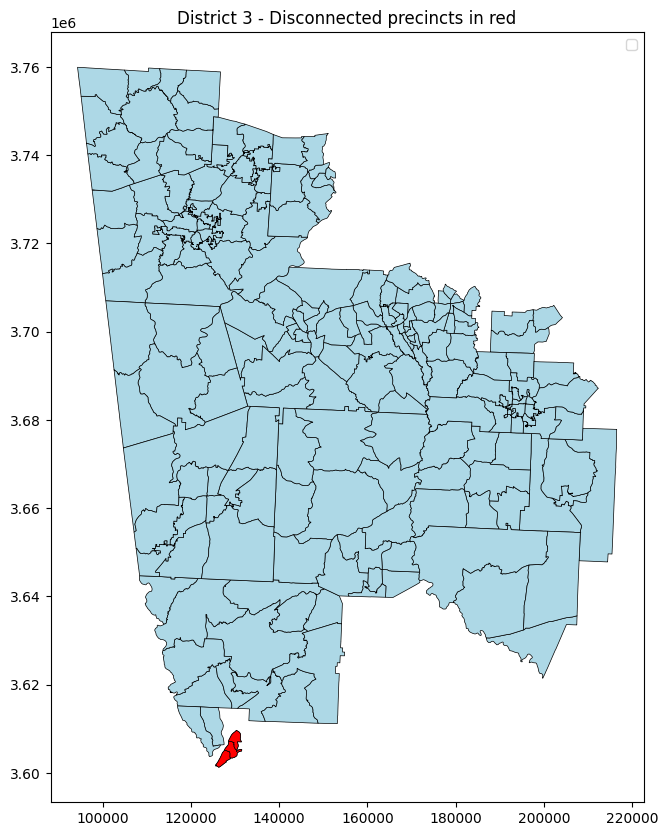

In [24]:
# Look at district 3 specifically
district_3_nodes = list(initial_partition.parts[3])
district_3_precincts = gdf[gdf.index.isin(district_3_nodes)]

# Check the subgraph connectivity
subgraph_3 = graph.subgraph(district_3_nodes)
components = list(nx.connected_components(subgraph_3))
print(f"Number of disconnected components in district 3: {len(components)}")

# Find the isolated precinct(s)
for i, component in enumerate(components):
    print(f"\nComponent {i+1}: {len(component)} precincts")
    component_precincts = gdf[gdf.index.isin(component)]
    print(component_precincts[["UNIQUE_ID", "District"]])

# Plot to visualize
fig, ax = plt.subplots(figsize=(12, 10))
district_3_precincts.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.5)

# Highlight the disconnected small component
small_component = min(components, key=len)
small_precincts = gdf[gdf.index.isin(small_component)]
small_precincts.plot(ax=ax, color="red", edgecolor="black", linewidth=0.5, label="Disconnected")
plt.legend()
plt.title("District 3 - Disconnected precincts in red")
plt.show()

In [25]:
# Find what district the disconnected precincts should belong to
for node in small_component:
    neighbors = list(graph.neighbors(node))
    neighbor_districts = [gdf.loc[n, "District"] for n in neighbors]
    print(f"Precinct {gdf.loc[node, 'UNIQUE_ID']} neighbors are in districts: {neighbor_districts}")
    
    # Reassign to the most common neighboring district
    correct_district = max(set(neighbor_districts), key=neighbor_districts.count)
    gdf.loc[node, "District"] = correct_district
    print(f"Reassigned to district {correct_district}")

# Rebuild graph and partition after fix
graph = Graph.from_geodataframe(gdf)
initial_partition = Partition(
    graph,
    assignment="District",
    updaters=my_updaters
)

# Verify fix
print("Contiguous:", constraints.contiguous(initial_partition))

Precinct MUSCOGEE-:-EPWORTH UMC neighbors are in districts: [np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
Reassigned to district 2
Precinct MUSCOGEE-:-ST. PETER neighbors are in districts: [np.int64(3), np.int64(2), np.int64(2)]
Reassigned to district 2
Precinct MUSCOGEE-:-BRITT DAVID neighbors are in districts: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
Reassigned to district 2
Contiguous: True


In [ ]:
district3_nodes = list(initial_partition.parts[3])
gdf[gdf.index.isin(district3_nodes)].plot()

In [ ]:
components = list(nx.connected_components(graph.subgraph(district3_nodes)))

for i, comp in enumerate(components):
    print(f"Component {i} size:", len(comp))
    
largest = max(components, key=len)
island = [c for c in components if c != largest][0]

print("Island nodes:", island)

In [ ]:
gdf.loc[list(island)].plot()

In [ ]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2
)

In [ ]:
recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=40
)

In [ ]:
district_plans = []

for i, plan in enumerate(recom_chain):
    print(f"Finished step {i+1}/{len(recom_chain)}", end="\r")
    district_plans.append(plan.assignment)